<a href="https://www.kaggle.com/code/aamir28/customer-churn-decoded-telco-analytics-and-ml?scriptVersionId=319964632" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a0f2c 0%, #0d2137 50%, #0a3d62 100%); border-radius: 20px; padding: 60px 50px 50px 50px; margin-bottom: 10px; border: 1px solid #1a4a7a; box-shadow: 0 20px 60px rgba(0,0,0,0.5);">

<div style="text-align:center; margin-bottom: 30px;">
  <span style="font-size:13px; letter-spacing:8px; color:#f0c040; font-weight:600; text-transform:uppercase;">Telecom Analytics · Churn Intelligence</span>
</div>

<h1 style="text-align:center; font-size:52px; font-weight:900; color:#ffffff; margin:0 0 16px 0; letter-spacing:-1px; line-height:1.1;">
  The Silent Exit
</h1>

<h2 style="text-align:center; font-size:22px; font-weight:300; color:#7ec8e3; margin:0 0 40px 0; font-style:italic; letter-spacing:1px;">
  Decoding Why Telecom Customers Leave — and How to Stop Them
</h2>

<p style="text-align:center; color:#a8c8e8; font-size:16px; max-width:680px; margin:0 auto 40px auto; line-height:1.8;">
  This notebook uncovers the hidden drivers behind telecom customer churn using premium analytics, business storytelling, and machine learning. Every chart has a story. Every model has a purpose.
</p>

<div style="display:flex; justify-content:center; gap:30px; flex-wrap:wrap; margin-bottom:40px;">
  <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(240,192,64,0.3); border-radius:12px; padding:16px 24px; text-align:center; min-width:130px;">
    <div style="color:#f0c040; font-size:22px; font-weight:700;">7,043</div>
    <div style="color:#7ec8e3; font-size:12px; letter-spacing:2px; text-transform:uppercase; margin-top:4px;">Customers</div>
  </div>
  <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(240,192,64,0.3); border-radius:12px; padding:16px 24px; text-align:center; min-width:130px;">
    <div style="color:#f0c040; font-size:22px; font-weight:700;">20</div>
    <div style="color:#7ec8e3; font-size:12px; letter-spacing:2px; text-transform:uppercase; margin-top:4px;">Features</div>
  </div>
  <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(240,192,64,0.3); border-radius:12px; padding:16px 24px; text-align:center; min-width:130px;">
    <div style="color:#f0c040; font-size:22px; font-weight:700;">26.5%</div>
    <div style="color:#7ec8e3; font-size:12px; letter-spacing:2px; text-transform:uppercase; margin-top:4px;">Churn Rate</div>
  </div>
  <div style="background:rgba(255,255,255,0.05); border:1px solid rgba(240,192,64,0.3); border-radius:12px; padding:16px 24px; text-align:center; min-width:130px;">
    <div style="color:#f0c040; font-size:22px; font-weight:700;">4 Models</div>
    <div style="color:#7ec8e3; font-size:12px; letter-spacing:2px; text-transform:uppercase; margin-top:4px;">Benchmarked</div>
  </div>
</div>

<hr style="border:none; border-top:1px solid rgba(126,200,227,0.2); margin:0 0 30px 0;" />

<div style="display:flex; justify-content:center; gap:60px; flex-wrap:wrap;">
  <div style="text-align:center;">
    <div style="color:#f0c040; font-size:13px; letter-spacing:3px; text-transform:uppercase; margin-bottom:6px;">What You'll Learn</div>
    <div style="color:#a8c8e8; font-size:14px; line-height:2;">
      ✦ Business-grade churn EDA<br>
      ✦ Feature engineering strategies<br>
      ✦ Multi-model ML benchmark<br>
      ✦ Actionable retention insights
    </div>
  </div>
  <div style="text-align:center;">
    <div style="color:#f0c040; font-size:13px; letter-spacing:3px; text-transform:uppercase; margin-bottom:6px;">Estimated Runtime</div>
    <div style="color:#a8c8e8; font-size:14px; line-height:2;">
      ✦ ~3–5 minutes on Kaggle<br>
      ✦ GPU not required<br>
      ✦ All libraries pre-installed<br>
      ✦ Fully reproducible
    </div>
  </div>
</div>

</div>

---

## 📡 The Business Problem

<div style="background: linear-gradient(to right, #0a1628, #0d2137); border-left: 4px solid #f0c040; border-radius: 8px; padding: 24px 28px; margin: 20px 0;">

**Customer churn** — the rate at which customers cancel their subscriptions — is the silent killer of telecom revenue.

In an industry where **acquiring a new customer costs 5–7× more than retaining an existing one**, a churn rate of just 2% per month compounds into a massive annual revenue leak.

For a telecom operator with **1 million subscribers** at an average monthly revenue of **$65/customer**:

> A **1% reduction in churn** translates to **~$7.8M in saved annual revenue**.

This notebook treats churn not as a classification problem — but as a **business intelligence challenge**.

</div>

| Dimension | Detail |
|---|---|
| **Industry** | Telecommunications |
| **Problem Type** | Binary Classification (Churn / No Churn) |
| **Business Goal** | Identify at-risk customers before they leave |
| **ML Objective** | Maximize Recall without sacrificing Precision |
| **Key Stakeholders** | Customer Success, Marketing, Product, Finance |

---
## ⚙️ Environment Setup

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

# ── Global Style ──────────────────────────────────────────────────────────────
PALETTE    = ['#0a3d62', '#1e87c9', '#f0c040', '#7ec8e3', '#e74c3c', '#2ecc71']
CHURN_COLS = {'No': '#1e87c9', 'Yes': '#f0c040'}
BG_DARK    = '#0a0f2c'
BG_MID     = '#0d2137'
TEXT_COLOR = '#e8f4f8'

plt.rcParams.update({
    'figure.facecolor': BG_DARK,
    'axes.facecolor':   BG_MID,
    'axes.edgecolor':   '#1a4a7a',
    'axes.labelcolor':  TEXT_COLOR,
    'xtick.color':      TEXT_COLOR,
    'ytick.color':      TEXT_COLOR,
    'text.color':       TEXT_COLOR,
    'grid.color':       '#1a4a7a',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.titlecolor':  '#f0c040',
})

PLOTLY_TEMPLATE = dict(
    layout=go.Layout(
        paper_bgcolor=BG_DARK,
        plot_bgcolor=BG_MID,
        font=dict(color=TEXT_COLOR, family='Arial'),
        title_font=dict(color='#f0c040', size=18),
        legend=dict(bgcolor='rgba(10,15,44,0.8)', bordercolor='#1a4a7a'),
    )
)

print("✅ Environment ready. All libraries loaded.")
print(f"   XGBoost  : {'✅' if XGB_AVAILABLE else '⚠️ not available'}")
print(f"   LightGBM : {'✅' if LGB_AVAILABLE else '⚠️ not available'}")


✅ Environment ready. All libraries loaded.
   XGBoost  : ✅
   LightGBM : ✅


---
## 📂 Loading the Dataset

In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Quick Fixes ───────────────────────────────────────────────────────────────
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Churn Rate  : {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")
print(f"Missing     : {df.isnull().sum().sum()} values")
print()
df.head(5)


Shape       : 7,043 rows × 21 columns
Churn Rate  : 26.5%
Missing     : 0 values



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# ── Schema Snapshot ──────────────────────────────────────────────────────────
info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.notnull().sum().values,
    'Unique': df.nunique().values,
    'Sample': [str(df[c].iloc[0]) for c in df.columns]
})
print(info.to_string(index=False))


          Column   Dtype  Non-Null  Unique           Sample
      customerID  object      7043    7043       7590-VHVEG
          gender  object      7043       2           Female
   SeniorCitizen  object      7043       2               No
         Partner  object      7043       2              Yes
      Dependents  object      7043       2               No
          tenure   int64      7043      73                1
    PhoneService  object      7043       2               No
   MultipleLines  object      7043       3 No phone service
 InternetService  object      7043       3              DSL
  OnlineSecurity  object      7043       3               No
    OnlineBackup  object      7043       3              Yes
DeviceProtection  object      7043       3               No
     TechSupport  object      7043       3               No
     StreamingTV  object      7043       3               No
 StreamingMovies  object      7043       3               No
        Contract  object      7043      

In [4]:
df.describe(include='all').T.style \
    .background_gradient(cmap='Blues', subset=['mean','std']) \
    .set_caption('📊 Statistical Summary')

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,nan,nan,nan,nan,nan,nan,nan
gender,7043,2,Male,3555,nan,nan,nan,nan,nan,nan,nan
SeniorCitizen,7043,2,No,5901,nan,nan,nan,nan,nan,nan,nan
Partner,7043,2,No,3641,nan,nan,nan,nan,nan,nan,nan
Dependents,7043,2,No,4933,nan,nan,nan,nan,nan,nan,nan
tenure,7043.000000,nan,nan,nan,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
PhoneService,7043,2,Yes,6361,nan,nan,nan,nan,nan,nan,nan
MultipleLines,7043,3,No,3390,nan,nan,nan,nan,nan,nan,nan
InternetService,7043,3,Fiber optic,3096,nan,nan,nan,nan,nan,nan,nan
OnlineSecurity,7043,3,No,3498,nan,nan,nan,nan,nan,nan,nan


---

## 🔍 Section 1 · Churn Distribution

> **First question a business always asks:** *How bad is it?*

A 26.5% churn rate is well above the telecom industry average of ~15–20%. This means **1 in 4 customers** is leaving. Understanding the "who" and "why" is the entire mission of this notebook.

In [5]:
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles=("Customer Churn Share", "Absolute Customer Count")
)

churn_counts = df['Churn'].value_counts()

fig.add_trace(go.Pie(
    labels=churn_counts.index,
    values=churn_counts.values,
    hole=0.55,
    marker=dict(colors=['#1e87c9', '#f0c040'],
                line=dict(color='#0a0f2c', width=3)),
    textinfo='label+percent',
    textfont_size=14,
    name='',
), row=1, col=1)

fig.add_trace(go.Bar(
    x=churn_counts.index,
    y=churn_counts.values,
    marker_color=['#1e87c9', '#f0c040'],
    text=churn_counts.values,
    textposition='outside',
    textfont=dict(size=14, color='#f0c040'),
    name='',
    width=0.4,
), row=1, col=2)

fig.update_layout(
    **PLOTLY_TEMPLATE['layout'].to_plotly_json(),  
    
    showlegend=False,
    height=420,
    annotations=[
        dict(text="<b>26.5%</b><br>Churn", x=0.195, y=0.5, font_size=16,
             showarrow=False, font_color='#f0c040'),
    ]
)
fig.update_yaxes(showgrid=True, gridcolor='#1a4a7a', row=1, col=2)
fig.show()

print("\n💡 KEY OBSERVATION")
print("   ├─ 5,174 customers retained  (73.5%)")
print("   ├─ 1,869 customers churned   (26.5%)")
print("   └─ Dataset is moderately imbalanced — we'll address this during modeling.")



💡 KEY OBSERVATION
   ├─ 5,174 customers retained  (73.5%)
   ├─ 1,869 customers churned   (26.5%)
   └─ Dataset is moderately imbalanced — we'll address this during modeling.


---

## 👥 Section 2 · Customer Demographics

> Does *who* you are predict whether you'll leave?

Demographics rarely explain churn alone — but they reveal **which customer segments** are most vulnerable and help marketing **target retention campaigns** more precisely.

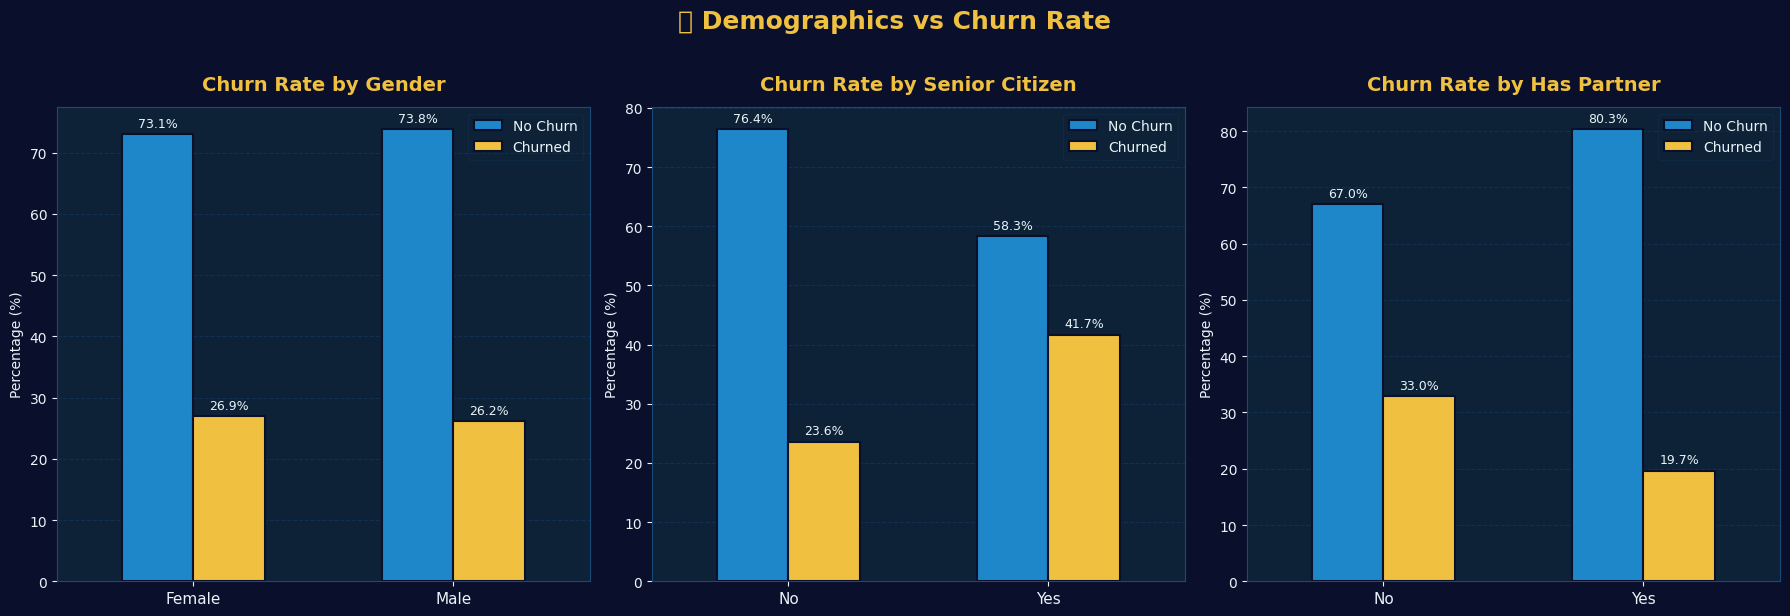


💡 KEY OBSERVATIONS
   ├─ Gender has almost NO impact on churn — don't segment by gender for retention.
   ├─ Senior Citizens churn at ~42% — nearly double the average. High-value focus group.
   └─ Customers WITHOUT a partner churn ~33% vs 20% with partner — loneliness = churn risk?


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)

demo_cols = ['gender', 'SeniorCitizen', 'Partner']
demo_labels = ['Gender', 'Senior Citizen', 'Has Partner']

for ax, col, label in zip(axes, demo_cols, demo_labels):
    ct = df.groupby([col, 'Churn']).size().unstack()
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(kind='bar', ax=ax, color=['#1e87c9', '#f0c040'],
                width=0.55, edgecolor='#0a0f2c', linewidth=1.5)
    ax.set_title(f'Churn Rate by {label}', pad=12)
    ax.set_xlabel('')
    ax.set_ylabel('Percentage (%)')
    ax.legend(['No Churn', 'Churned'], framealpha=0.2,
              facecolor=BG_MID, edgecolor='#1a4a7a')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9, padding=3, color=TEXT_COLOR)

plt.suptitle('👥 Demographics vs Churn Rate', fontsize=18, color='#f0c040',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY OBSERVATIONS")
print("   ├─ Gender has almost NO impact on churn — don't segment by gender for retention.")
print("   ├─ Senior Citizens churn at ~42% — nearly double the average. High-value focus group.")
print("   └─ Customers WITHOUT a partner churn ~33% vs 20% with partner — loneliness = churn risk?")


---

## 🌐 Section 3 · Service Portfolio Analysis

> *Which services protect customers — and which ones don't?*

The services a customer subscribes to are powerful churn predictors. Sticky services (bundles, security, support) create **switching costs** and increase retention. Knowing which services act as "churn shields" is pure gold for product strategy.

In [7]:
service_cols = ['InternetService', 'OnlineSecurity', 'TechSupport',
                'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']

churn_rates = {}
for col in service_cols:
    rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    churn_rates[col] = rate

fig = make_subplots(rows=3, cols=3,
                    subplot_titles=[c.replace('_',' ') for c in service_cols] + ['',''],
                    vertical_spacing=0.12, horizontal_spacing=0.08)

positions = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3),(3,1)]
for (r,c), col in zip(positions, service_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
    rate.columns = [col, 'ChurnRate']
    colors = ['#f0c040' if v > 30 else '#1e87c9' for v in rate['ChurnRate']]
    fig.add_trace(
        go.Bar(x=rate[col], y=rate['ChurnRate'],
               marker_color=colors,
               text=[f"{v:.1f}%" for v in rate['ChurnRate']],
               textposition='outside', textfont=dict(size=11),
               name=col, showlegend=False),
        row=r, col=c
    )
    fig.update_yaxes(range=[0, 65], row=r, col=c)

fig.update_layout(
    **PLOTLY_TEMPLATE['layout'].to_plotly_json(),
    
    height=700,
)
fig.show()

print("\n💡 KEY OBSERVATIONS")
print("   ├─ Fiber Optic internet churns at ~42% — despite being premium. Price sensitivity?")
print("   ├─ Customers with NO Online Security churn at 3× the rate of those with it.")
print("   ├─ No Tech Support = ~41% churn rate. Support IS retention.")
print("   └─ Streaming services show moderate churn — not strong predictors either way.")



💡 KEY OBSERVATIONS
   ├─ Fiber Optic internet churns at ~42% — despite being premium. Price sensitivity?
   ├─ Customers with NO Online Security churn at 3× the rate of those with it.
   ├─ No Tech Support = ~41% churn rate. Support IS retention.
   └─ Streaming services show moderate churn — not strong predictors either way.


---

## 💰 Section 4 · Financial Deep Dive

> *Money talks — especially when customers are about to leave.*

Monthly charges, total charges, and contract types are among the **strongest financial signals** for churn. Understanding the price sensitivity of churners helps build smarter pricing and retention discount strategies.

In [8]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=('Monthly Charges Distribution', 'Total Charges Distribution'))

for churn_val, color, fillcolor in [('No', '#1e87c9', 'rgba(30,135,201,0.3)'),
                                      ('Yes', '#f0c040', 'rgba(240,192,64,0.3)')]:
    subset = df[df['Churn'] == churn_val]
    fig.add_trace(go.Violin(x=[churn_val]*len(subset),
                            y=subset['MonthlyCharges'],
                            name=f"Churn={churn_val}",
                            line_color=color,
                            fillcolor=fillcolor,
                            box_visible=True, 
                            meanline_visible=True,
                            showlegend=(churn_val=='No')),
                  row=1, col=1)
    fig.add_trace(go.Violin(x=[churn_val]*len(subset),
                            y=subset['TotalCharges'],
                            name=f"Churn={churn_val}",
                            line_color=color,
                            fillcolor=fillcolor,
                            box_visible=True, 
                            meanline_visible=True,
                            showlegend=False),
                  row=1, col=2)

fig.update_layout(
    **PLOTLY_TEMPLATE['layout'].to_plotly_json(),
    height=450, 
    showlegend=True
)
fig.show()

print("\n💡 KEY OBSERVATIONS")
print("   ├─ Churners pay significantly HIGHER monthly charges (~$74 vs $61 for non-churners).")
print("   ├─ Churners have LOWER total charges — they leave early in their lifecycle.")
print("   └─ High price + short tenure = maximum churn risk. This is the danger zone.")


💡 KEY OBSERVATIONS
   ├─ Churners pay significantly HIGHER monthly charges (~$74 vs $61 for non-churners).
   ├─ Churners have LOWER total charges — they leave early in their lifecycle.
   └─ High price + short tenure = maximum churn risk. This is the danger zone.


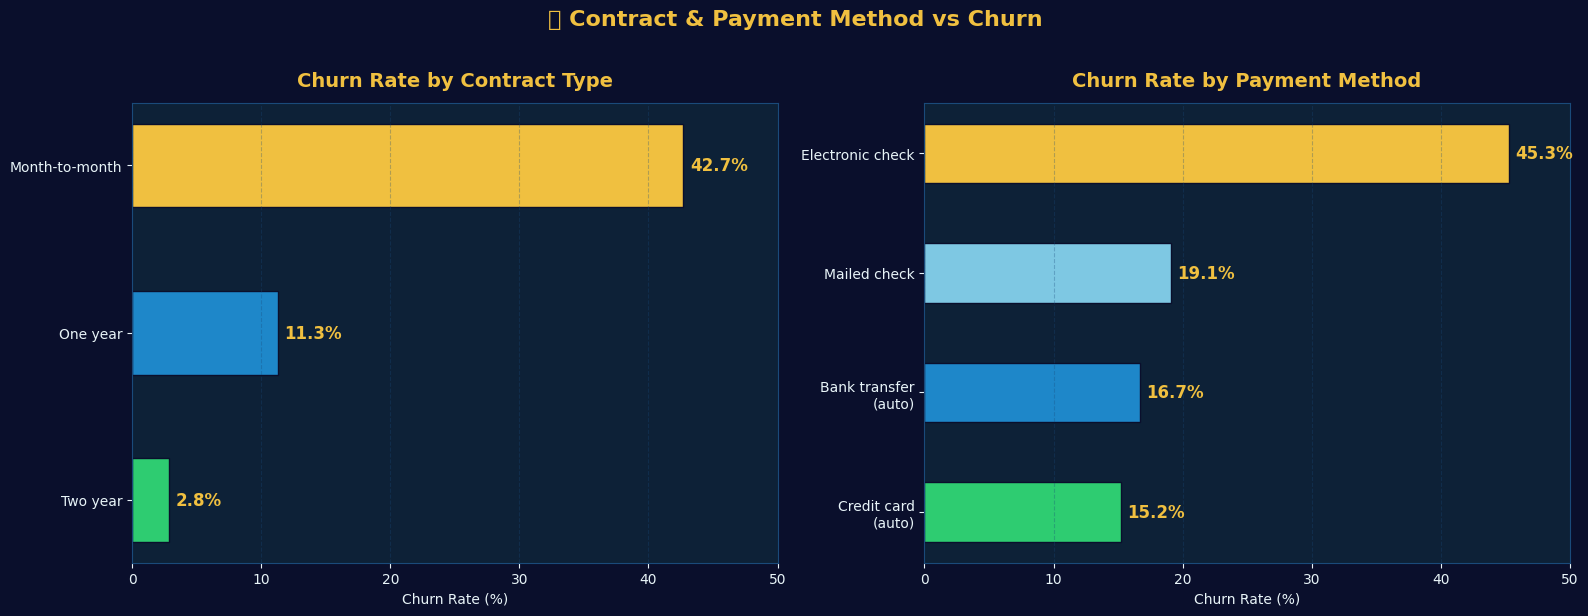


💡 KEY OBSERVATIONS
   ├─ Month-to-month contracts = 43% churn. Two-year = just 3%. Locking = retaining.
   ├─ Electronic check users churn at 45% — nearly double any auto-payment method.
   └─ Auto-pay customers are far more loyal. Encouraging auto-pay = quick retention win.


In [9]:
# ── Contract Type & Payment Method ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)

# Contract
ct = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
ct.columns = ['Contract', 'ChurnRate']
ct = ct.sort_values('ChurnRate', ascending=True)
bars = axes[0].barh(ct['Contract'], ct['ChurnRate'],
                    color=['#2ecc71','#1e87c9','#f0c040'], height=0.5, edgecolor='#0a0f2c')
axes[0].set_title('Churn Rate by Contract Type', pad=12)
axes[0].set_xlabel('Churn Rate (%)')
for i, (val, bar) in enumerate(zip(ct['ChurnRate'], bars)):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=12, color='#f0c040', fontweight='bold')
axes[0].set_xlim(0, 50)
axes[0].grid(axis='x', alpha=0.3)

# Payment
pm = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x=='Yes').mean()*100).reset_index()
pm.columns = ['PaymentMethod', 'ChurnRate']
pm = pm.sort_values('ChurnRate', ascending=True)
pm['PaymentMethod'] = pm['PaymentMethod'].str.replace(' (automatic)', '\n(auto)', regex=False)
bars2 = axes[1].barh(pm['PaymentMethod'], pm['ChurnRate'],
                     color=['#2ecc71','#1e87c9','#7ec8e3','#f0c040'], height=0.5, edgecolor='#0a0f2c')
axes[1].set_title('Churn Rate by Payment Method', pad=12)
axes[1].set_xlabel('Churn Rate (%)')
for val, bar in zip(pm['ChurnRate'], bars2):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=12, color='#f0c040', fontweight='bold')
axes[1].set_xlim(0, 50)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('📋 Contract & Payment Method vs Churn', fontsize=16, color='#f0c040',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY OBSERVATIONS")
print("   ├─ Month-to-month contracts = 43% churn. Two-year = just 3%. Locking = retaining.")
print("   ├─ Electronic check users churn at 45% — nearly double any auto-payment method.")
print("   └─ Auto-pay customers are far more loyal. Encouraging auto-pay = quick retention win.")


---

## ⏳ Section 5 · Tenure & Customer Loyalty

> *Time is the ultimate loyalty test.*

Tenure — how long a customer has been with the company — is one of the **single most powerful churn predictors**. The first few months are critical. If a customer survives past 12–24 months, retention probability skyrockets.

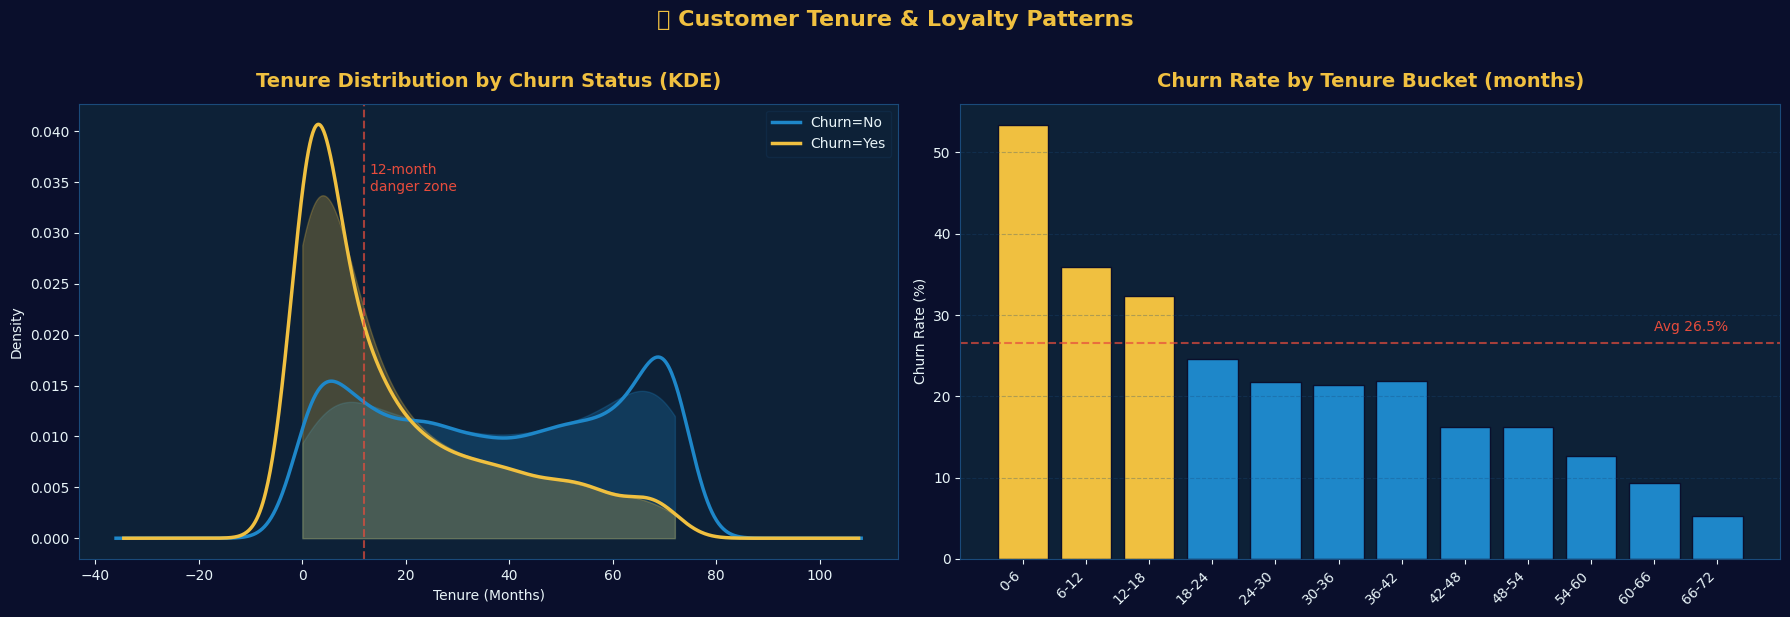


💡 KEY OBSERVATIONS
   ├─ Customers in the 0–12 month window have the highest churn risk (40%+).
   ├─ After 48+ months, churn drops below 10% — loyalty compounds over time.
   └─ Strategy: Invest heavily in the onboarding experience for new customers.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)

# KDE Plot
for churn_val, color in [('No', '#1e87c9'), ('Yes', '#f0c040')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    subset.plot.kde(ax=axes[0], color=color, linewidth=2.5, label=f'Churn={churn_val}')
    axes[0].fill_between(np.linspace(subset.min(), subset.max(), 200),
                         0, [0]*200, alpha=0)

# Manual KDE fill
from scipy.stats import gaussian_kde
for churn_val, color, alpha in [('No','#1e87c9',0.25), ('Yes','#f0c040',0.25)]:
    subset = df[df['Churn']==churn_val]['tenure'].values
    kde = gaussian_kde(subset, bw_method=0.3)
    x_range = np.linspace(0, 72, 300)
    y_vals = kde(x_range)
    axes[0].fill_between(x_range, y_vals, alpha=alpha, color=color)

axes[0].set_title('Tenure Distribution by Churn Status (KDE)', pad=12)
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Density')
axes[0].legend(framealpha=0.2, facecolor=BG_MID, edgecolor='#1a4a7a')
axes[0].axvline(12, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].text(13, axes[0].get_ylim()[1]*0.8, '12-month\ndanger zone',
             color='#e74c3c', fontsize=10)

# Monthly churn rate over tenure
df['tenure_bucket'] = pd.cut(df['tenure'], bins=range(0, 73, 6),
                              labels=[f'{i}-{i+6}' for i in range(0, 72, 6)])
monthly_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
monthly_churn.columns = ['Tenure Range', 'ChurnRate']

colors_bar = ['#f0c040' if v > 30 else '#1e87c9' for v in monthly_churn['ChurnRate']]
axes[1].bar(range(len(monthly_churn)), monthly_churn['ChurnRate'],
            color=colors_bar, edgecolor='#0a0f2c', linewidth=1)
axes[1].set_xticks(range(len(monthly_churn)))
axes[1].set_xticklabels(monthly_churn['Tenure Range'], rotation=45, ha='right')
axes[1].set_title('Churn Rate by Tenure Bucket (months)', pad=12)
axes[1].set_ylabel('Churn Rate (%)')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(26.5, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].text(10, 28, 'Avg 26.5%', color='#e74c3c', fontsize=10)

plt.suptitle('⏳ Customer Tenure & Loyalty Patterns', fontsize=16,
             color='#f0c040', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 KEY OBSERVATIONS")
print("   ├─ Customers in the 0–12 month window have the highest churn risk (40%+).")
print("   ├─ After 48+ months, churn drops below 10% — loyalty compounds over time.")
print("   └─ Strategy: Invest heavily in the onboarding experience for new customers.")


---

## 🌌 Section 6 · Multi-Dimensional Sunburst

> Visualizing churn across **Contract → Internet → Senior Citizen** simultaneously.

In [11]:
# Aggregate for sunburst
sb_df = df.groupby(['Contract', 'InternetService', 'SeniorCitizen', 'Churn']).size().reset_index(name='count')

fig = px.sunburst(
    sb_df,
    path=['Contract', 'InternetService', 'Churn'],
    values='count',
    color='Churn',
    color_discrete_map={'Yes': '#f0c040', 'No': '#1e87c9', '(?)': '#0a3d62'},
    title='🌌 Churn Hierarchy: Contract → Internet Service → Churn Status',
)
fig.update_layout(
    **PLOTLY_TEMPLATE['layout'].to_plotly_json(),
    height=550,
)
fig.update_traces(textfont=dict(size=12))
fig.show()

print("\n💡 The sunburst reveals that the most dangerous segment is:")
print("   Month-to-month + Fiber Optic → this single cohort drives a disproportionate share of churn.")



💡 The sunburst reveals that the most dangerous segment is:
   Month-to-month + Fiber Optic → this single cohort drives a disproportionate share of churn.


---

## 🔥 Section 7 · Correlation Intelligence

> *Which features move together — and how do they relate to churn?*

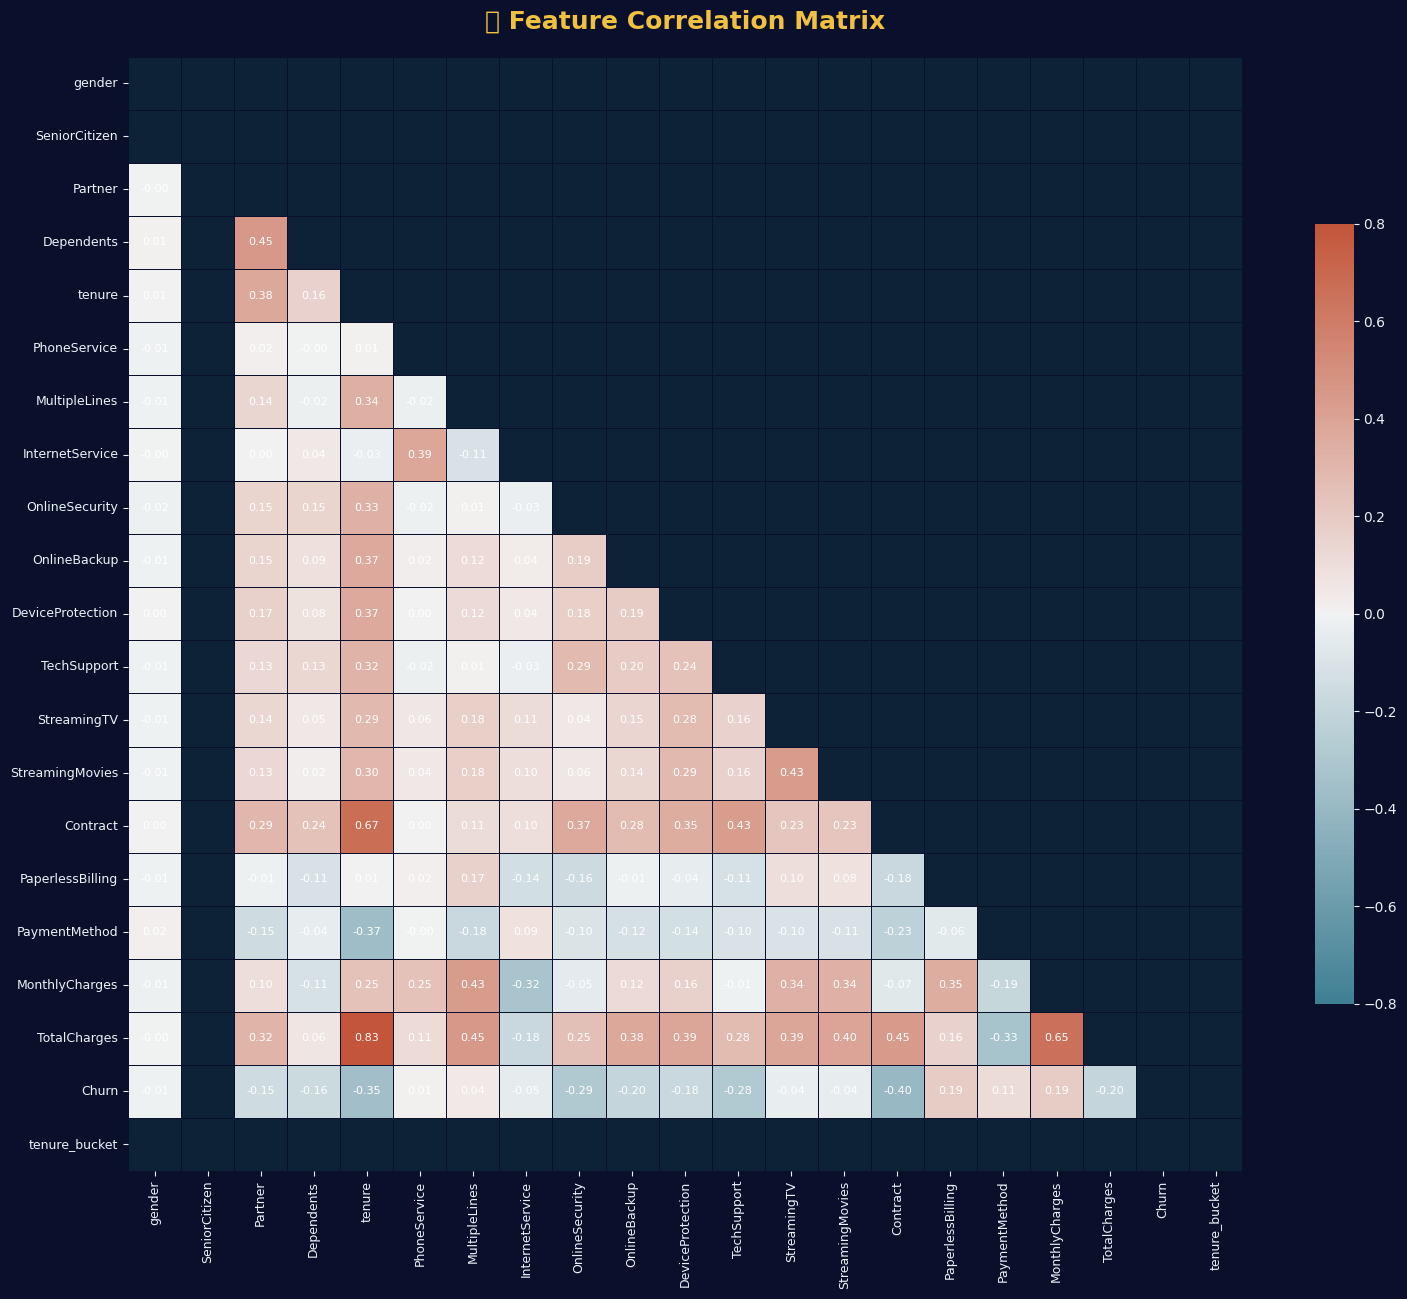


📊 Top Features Correlated with Churn:
   ▼ Contract                  -0.397
   ▼ tenure                    -0.352
   ▼ OnlineSecurity            -0.289
   ▼ TechSupport               -0.282
   ▼ TotalCharges              -0.199
   ▼ OnlineBackup              -0.196
   ▲ MonthlyCharges            +0.193
   ▲ PaperlessBilling          +0.192


In [12]:
# Encode for correlation
df_enc = df.copy()

# First, handle any columns that might have range strings
if 'SeniorCitizen' in df_enc.columns:
    df_enc['SeniorCitizen'] = pd.to_numeric(df_enc['SeniorCitizen'], errors='coerce')

# Handle TotalCharges conversion
if 'TotalCharges' in df_enc.columns:
    df_enc['TotalCharges'] = pd.to_numeric(df_enc['TotalCharges'], errors='coerce')
    df_enc['TotalCharges'].fillna(0, inplace=True)

# Encode categorical columns
le = LabelEncoder()
for col in df_enc.select_dtypes('object').columns:
    if col != 'customerID':
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Drop customerID
if 'customerID' in df_enc.columns:
    df_enc.drop('customerID', axis=1, inplace=True)

# Convert all columns to numeric, coercing errors to NaN
df_enc = df_enc.apply(pd.to_numeric, errors='coerce')

# Fill any remaining NaN values with 0
df_enc.fillna(0, inplace=True)

# Now calculate correlation
corr = df_enc.corr()

fig, ax = plt.subplots(figsize=(16, 13))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_MID)

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=0.8, vmin=-0.8,
            center=0, square=True, linewidths=0.5, linecolor='#0a0f2c',
            annot=True, fmt='.2f', annot_kws={'size': 8, 'color': 'white'},
            ax=ax, cbar_kws={'shrink': 0.7})

ax.set_title('🔥 Feature Correlation Matrix', fontsize=18, color='#f0c040',
             pad=20, fontweight='bold')
ax.tick_params(colors=TEXT_COLOR, labelsize=9)
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print("\n📊 Top Features Correlated with Churn:")
for feat, val in churn_corr.head(8).items():
    direction = '▲' if val > 0 else '▼'
    print(f"   {direction} {feat:<25} {val:+.3f}")

---

## 🛠️ Section 8 · Feature Engineering

> *Raw data is data. Engineered features are insights waiting to happen.*

We'll create domain-driven features that capture **customer risk profiles**, **spending behavior**, and **service stickiness** — signals that raw columns can't express alone.

In [13]:
df_fe = df.copy()

# ── 1. Tenure Groups ───────────────────────────────────────────────────────────
df_fe['TenureGroup'] = pd.cut(df_fe['tenure'],
                               bins=[0, 12, 24, 48, 72],
                               labels=['New (0-12)', 'Developing (12-24)',
                                       'Established (24-48)', 'Loyal (48-72)'])

# ── 2. Number of Services ──────────────────────────────────────────────────────
service_features = ['PhoneService','MultipleLines','InternetService',
                    'OnlineSecurity','OnlineBackup','DeviceProtection',
                    'TechSupport','StreamingTV','StreamingMovies']
df_fe['ServiceCount'] = (df_fe[service_features]
                          .apply(lambda col: col.isin(['Yes', 'DSL', 'Fiber optic']).astype(int))
                          .sum(axis=1))

# ── 3. Spending Category ───────────────────────────────────────────────────────
df_fe['SpendCategory'] = pd.cut(df_fe['MonthlyCharges'],
                                 bins=[0, 35, 65, 95, 120],
                                 labels=['Budget', 'Mid-Range', 'Premium', 'Ultra'])

# ── 4. Charge per Tenure Month ────────────────────────────────────────────────
df_fe['ChargePerMonth'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)

# ── 5. Has Security Bundle (Online Security + Tech Support) ───────────────────
df_fe['SecurityBundle'] = ((df_fe['OnlineSecurity']=='Yes') &
                            (df_fe['TechSupport']=='Yes')).astype(int)

# ── 6. Is Long-Term Contract ──────────────────────────────────────────────────
df_fe['LongTermContract'] = df_fe['Contract'].isin(['One year', 'Two year']).astype(int)

# ── 7. Composite Risk Score ───────────────────────────────────────────────────
df_fe['RiskScore'] = (
    (df_fe['Contract'] == 'Month-to-month').astype(int) * 2 +
    (df_fe['tenure'] < 12).astype(int) * 2 +
    (df_fe['MonthlyCharges'] > 70).astype(int) +
    (df_fe['PaymentMethod'] == 'Electronic check').astype(int) +
    (df_fe['OnlineSecurity'] == 'No').astype(int) +
    (df_fe['TechSupport'] == 'No').astype(int)
)

print("✅ Feature Engineering Complete")
print(f"\nNew features created:")
new_feats = ['TenureGroup','ServiceCount','SpendCategory',
             'ChargePerMonth','SecurityBundle','LongTermContract','RiskScore']
for f in new_feats:
    print(f"   ✦ {f:<22} | {df_fe[f].dtype} | Sample: {df_fe[f].iloc[0]}")


✅ Feature Engineering Complete

New features created:
   ✦ TenureGroup            | category | Sample: New (0-12)
   ✦ ServiceCount           | int64 | Sample: 2
   ✦ SpendCategory          | category | Sample: Budget
   ✦ ChargePerMonth         | float64 | Sample: 14.925
   ✦ SecurityBundle         | int64 | Sample: 0
   ✦ LongTermContract       | int64 | Sample: 0
   ✦ RiskScore              | int64 | Sample: 7


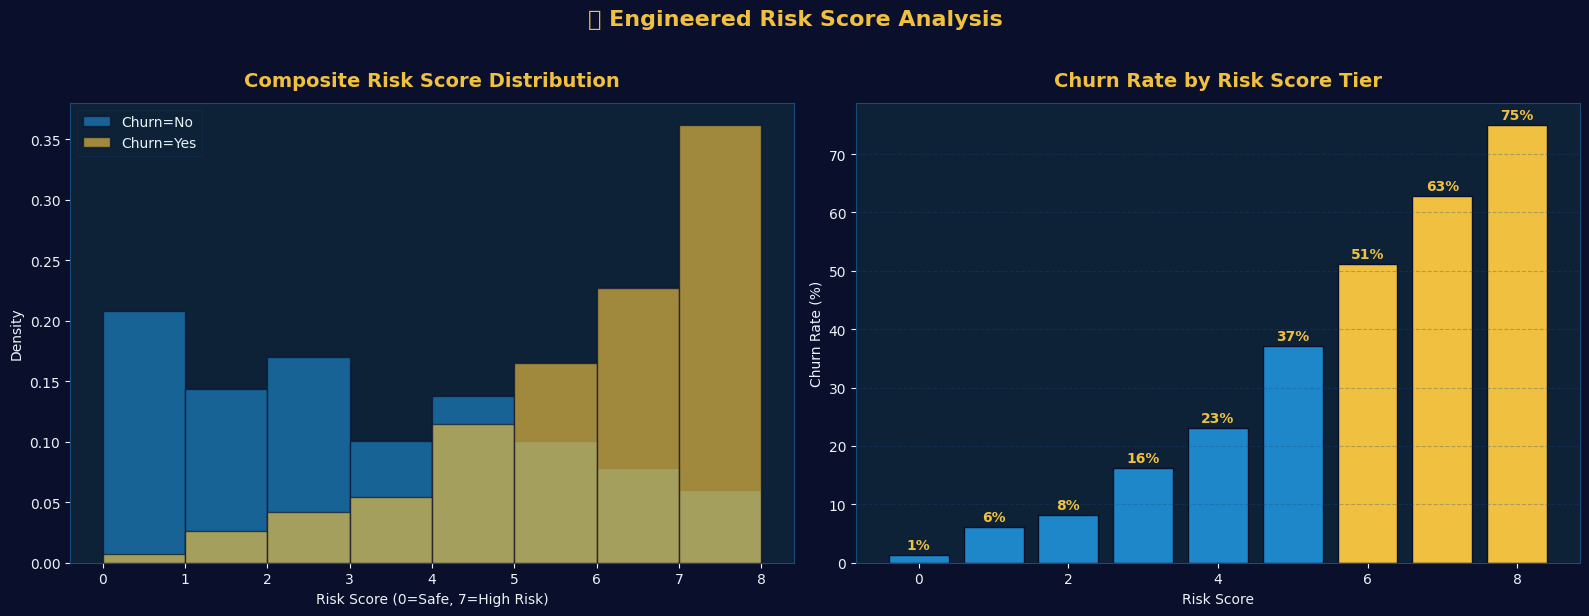

In [14]:
# Visualize Risk Score vs Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)

# Risk Score Distribution
for churn_val, color in [('No','#1e87c9'), ('Yes','#f0c040')]:
    subset = df_fe[df_fe['Churn']==churn_val]['RiskScore']
    axes[0].hist(subset, bins=range(0, 9), alpha=0.65, color=color,
                 label=f'Churn={churn_val}', edgecolor='#0a0f2c', density=True)
axes[0].set_title('Composite Risk Score Distribution', pad=12)
axes[0].set_xlabel('Risk Score (0=Safe, 7=High Risk)')
axes[0].set_ylabel('Density')
axes[0].legend(framealpha=0.2, facecolor=BG_MID, edgecolor='#1a4a7a')

# Risk Score → Churn Rate
risk_churn = df_fe.groupby('RiskScore')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
risk_churn.columns = ['RiskScore', 'ChurnRate']
bars = axes[1].bar(risk_churn['RiskScore'], risk_churn['ChurnRate'],
                   color=['#f0c040' if v>50 else '#1e87c9' for v in risk_churn['ChurnRate']],
                   edgecolor='#0a0f2c', linewidth=1)
axes[1].set_title('Churn Rate by Risk Score Tier', pad=12)
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, risk_churn['ChurnRate']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontsize=10, color='#f0c040', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('🛠️ Engineered Risk Score Analysis', fontsize=16, color='#f0c040',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


---

## ⚗️ Section 9 · Data Preprocessing

> Clean pipelines produce reliable models. Noisy pipelines produce unreliable metrics.

In [15]:
# ── Preprocessing Pipeline ───────────────────────────────────────────────────
df_model = df_fe.copy()

# Drop non-predictive columns
df_model.drop(columns=['customerID', 'tenure_bucket'], inplace=True, errors='ignore')

# Encode categoricals
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'Churn']

le_encoders = {}
for col in categorical_cols:
    le_enc = LabelEncoder()
    df_model[col] = le_enc.fit_transform(df_model[col].astype(str))
    le_encoders[col] = le_enc

# Encode ordered categoricals
for col in ['TenureGroup', 'SpendCategory']:
    if col in df_model.columns:
        le_enc = LabelEncoder()
        df_model[col] = le_enc.fit_transform(df_model[col].astype(str))

# Target
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Features / Target split
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Preprocessing Complete")
print(f"   Train size : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test size  : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Features   : {X_train.shape[1]}")
print(f"   Target rate: {y_train.mean()*100:.1f}% churn in train set")


✅ Preprocessing Complete
   Train size : 5,634 samples (80%)
   Test size  : 1,409 samples (20%)
   Features   : 26
   Target rate: 26.5% churn in train set


---

## 🤖 Section 10 · Machine Learning Benchmark

> *Four models enter. One wins. All teach us something.*

We benchmark four algorithms ranging from interpretable (Logistic Regression) to ensemble powerhouses (Random Forest, Gradient Boosting, XGBoost/LightGBM). Cross-validated to avoid overfitting illusions.

In [16]:
# ── Model Definitions ────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                                       max_depth=4, random_state=42),
}

if LGB_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                          num_leaves=31, random_state=42, verbose=-1)
elif XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                            max_depth=4, random_state=42,
                                            use_label_encoder=False, eval_metric='logloss')

# ── Training & Evaluation ─────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    print(f"  Training {name}...", end='')
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    cv_auc  = cross_val_score(model, X_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV AUC':    cv_auc.mean(),
        'CV Std':    cv_auc.std(),
        'y_proba':   y_proba,
        'model':     model,
    }
    print(f"  ✅  ROC-AUC={roc_auc_score(y_test, y_proba):.4f}  CV={cv_auc.mean():.4f}±{cv_auc.std():.4f}")

print("\n✅ All models trained and evaluated.")


  Training Logistic Regression...  ✅  ROC-AUC=0.8466  CV=0.8471±0.0122
  Training Random Forest...  ✅  ROC-AUC=0.8437  CV=0.8448±0.0099
  Training Gradient Boosting...  ✅  ROC-AUC=0.8361  CV=0.8408±0.0092
  Training LightGBM...  ✅  ROC-AUC=0.8339  CV=0.8330±0.0100

✅ All models trained and evaluated.


---

## 📊 Section 11 · Model Comparison Dashboard

In [17]:
# ── Results Table ────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ['y_proba', 'model']}
    for name, res in results.items()
}).T.drop(columns=['CV Std'])

metrics_df = metrics_df.astype(float).round(4)
best_model_name = metrics_df['ROC-AUC'].idxmax()

print(f"🏆 Best Model: {best_model_name}")
print()
metrics_df.style \
    .background_gradient(cmap='YlOrRd', subset=['ROC-AUC','CV AUC','F1 Score']) \
    .highlight_max(color='#f0c040', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC']) \
    .format('{:.4f}') \
    .set_caption(f"📊 Model Comparison — Best: {best_model_name}")


🏆 Best Model: Logistic Regression



,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV AUC
Logistic Regression,0.8070,0.6723,0.5321,0.5940,0.8466,0.8471
Random Forest,0.7999,0.6533,0.5241,0.5816,0.8437,0.8448
Gradient Boosting,0.7921,0.6319,0.5187,0.5698,0.8361,0.8408
LightGBM,0.7906,0.6312,0.5080,0.5630,0.8339,0.8330


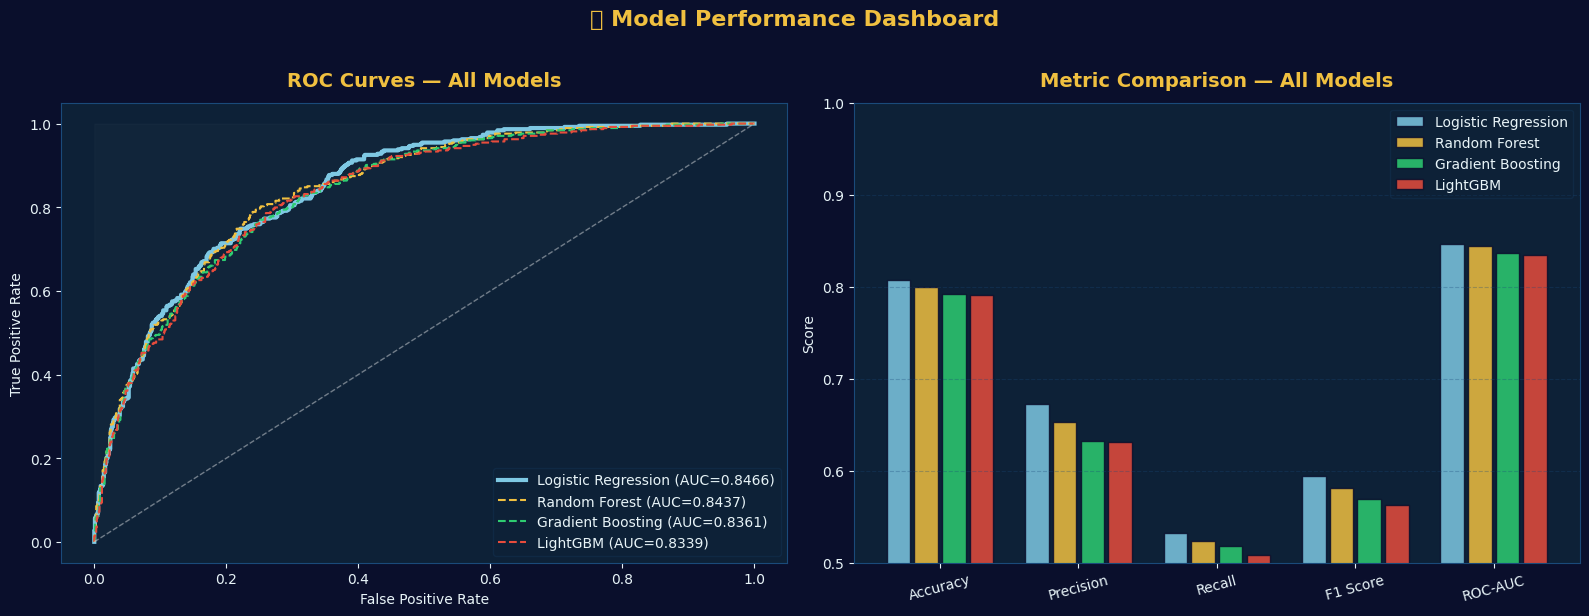

In [18]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_DARK)

colors_roc = ['#7ec8e3', '#f0c040', '#2ecc71', '#e74c3c']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = res['ROC-AUC']
    lw = 3 if name == best_model_name else 1.5
    ls = '-' if name == best_model_name else '--'
    axes[0].plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
                 label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1], 'w--', alpha=0.4, linewidth=1)
axes[0].fill_between([0,1],[0,1],[1,1], alpha=0.02, color='white')
axes[0].set_title('ROC Curves — All Models', pad=12)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(framealpha=0.2, facecolor=BG_MID, edgecolor='#1a4a7a', fontsize=10)

# Metric comparison radar-style bar
metric_names = ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']
x_pos = np.arange(len(metric_names))
width = 0.8 / len(results)

for i, ((name, res), color) in enumerate(zip(results.items(), colors_roc)):
    vals = [res[m] for m in metric_names]
    offset = (i - len(results)/2 + 0.5) * width
    axes[1].bar(x_pos + offset, vals, width=width*0.85, color=color, label=name,
                alpha=0.85, edgecolor='#0a0f2c')

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(metric_names, rotation=15)
axes[1].set_title('Metric Comparison — All Models', pad=12)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(framealpha=0.2, facecolor=BG_MID, edgecolor='#1a4a7a', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('📊 Model Performance Dashboard', fontsize=16, color='#f0c040',
             y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


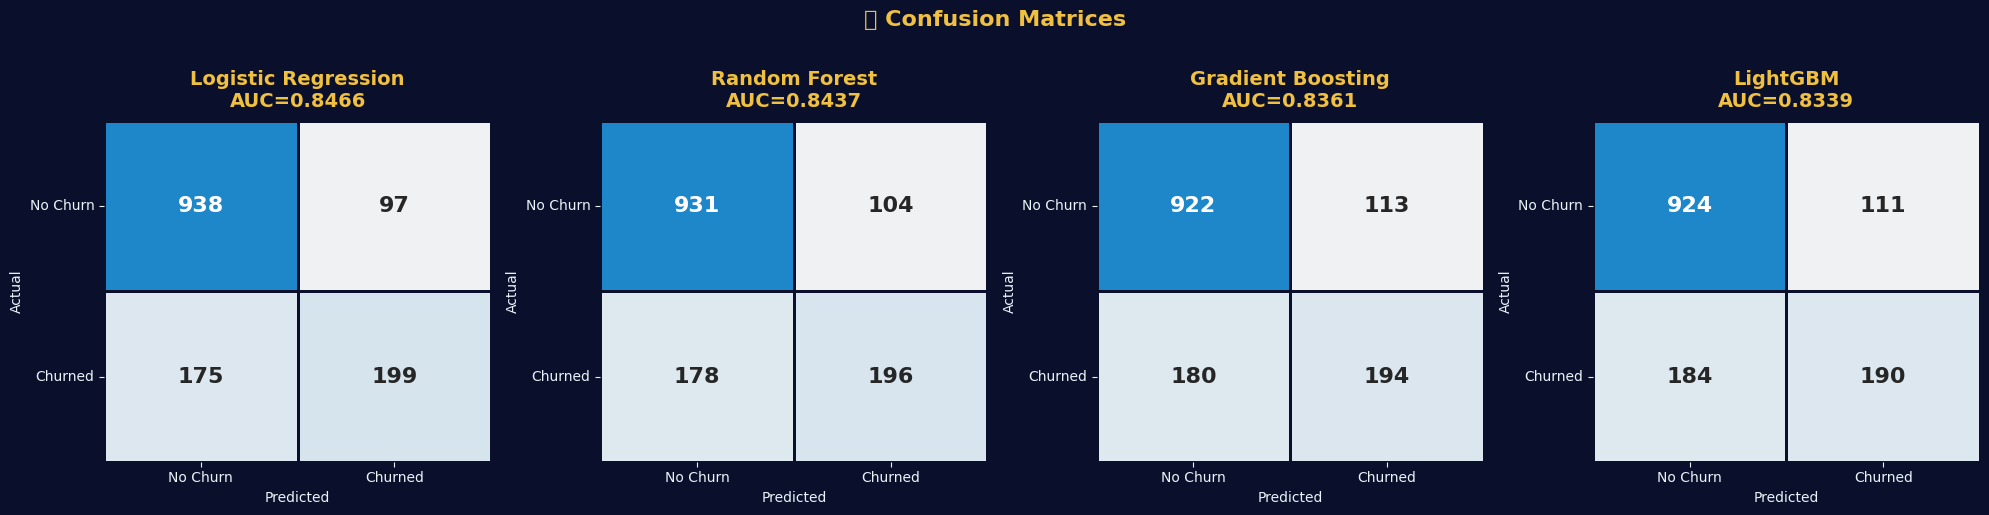

In [19]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))
fig.patch.set_facecolor(BG_DARK)
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    y_pred_cm = res['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred_cm)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap=sns.light_palette('#1e87c9', as_cmap=True),
                linewidths=2, linecolor='#0a0f2c',
                annot_kws={'size': 16, 'weight': 'bold'},
                cbar=False)
    ax.set_title(f'{name}\nAUC={res["ROC-AUC"]:.4f}', color='#f0c040', pad=10)
    ax.set_xlabel('Predicted', color=TEXT_COLOR)
    ax.set_ylabel('Actual', color=TEXT_COLOR)
    ax.set_xticklabels(['No Churn','Churned'])
    ax.set_yticklabels(['No Churn','Churned'], rotation=0)

plt.suptitle('🎯 Confusion Matrices', fontsize=16, color='#f0c040', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 🎯 Section 12 · Feature Importance

> *What does the model consider most predictive — and does it align with business intuition?*

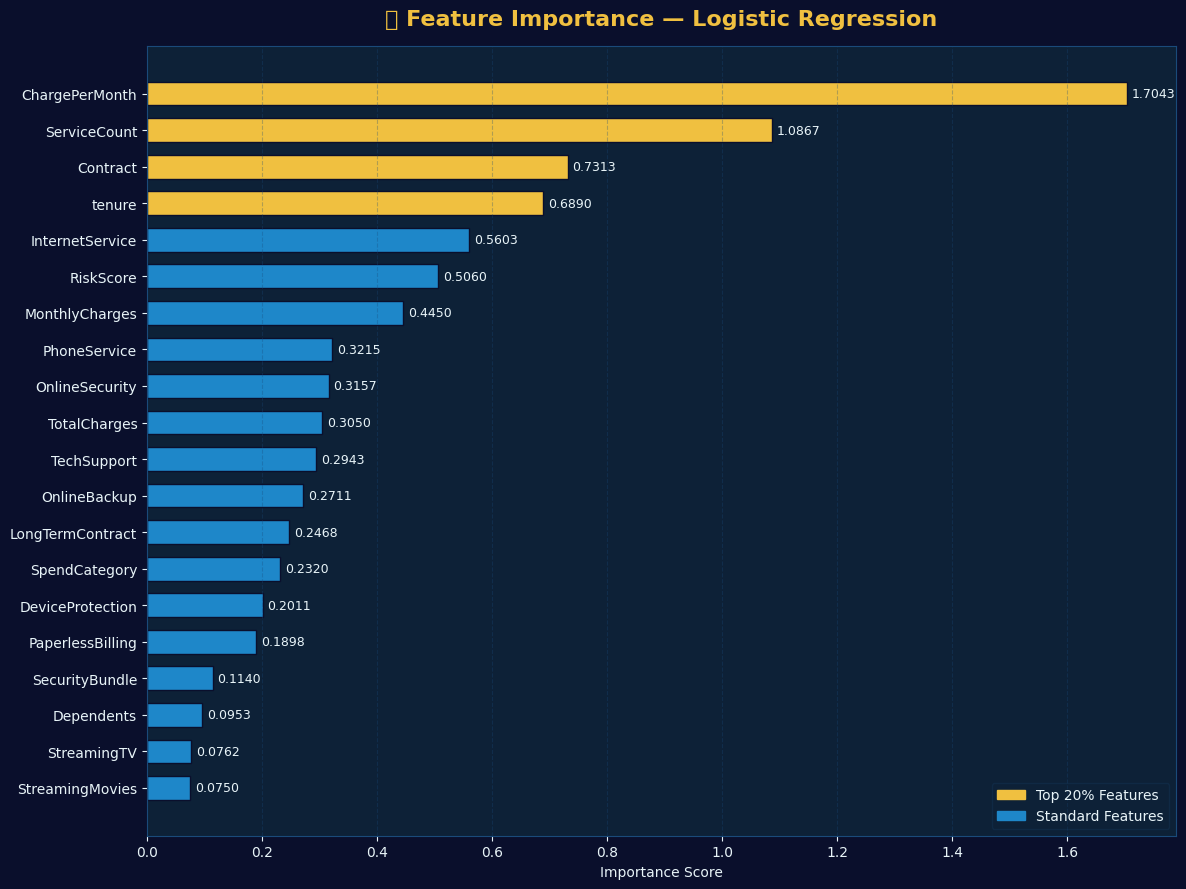


🏅 Top 5 Most Important Features (Logistic Regression):
   ✦ ChargePerMonth                 1.704272
   ✦ ServiceCount                   1.086698
   ✦ Contract                       0.731320
   ✦ tenure                         0.688971
   ✦ InternetService                0.560335


In [20]:
# Use best model (tree-based) for feature importance
best = results[best_model_name]['model']

if hasattr(best, 'feature_importances_'):
    fi = pd.Series(best.feature_importances_, index=X.columns)
elif hasattr(best, 'coef_'):
    fi = pd.Series(np.abs(best.coef_[0]), index=X.columns)
else:
    fi = pd.Series([0]*len(X.columns), index=X.columns)

fi = fi.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(BG_DARK)

colors_fi = ['#f0c040' if v > fi.quantile(0.8) else '#1e87c9' for v in fi.values]
bars = ax.barh(fi.index, fi.values, color=colors_fi, edgecolor='#0a0f2c', height=0.65)

ax.set_title(f'🎯 Feature Importance — {best_model_name}', fontsize=16,
             color='#f0c040', pad=15, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, fi.values):
    ax.text(val + fi.max()*0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color=TEXT_COLOR)

gold_patch = mpatches.Patch(color='#f0c040', label='Top 20% Features')
blue_patch = mpatches.Patch(color='#1e87c9', label='Standard Features')
ax.legend(handles=[gold_patch, blue_patch], framealpha=0.2,
          facecolor=BG_MID, edgecolor='#1a4a7a')

plt.tight_layout()
plt.show()

print(f"\n🏅 Top 5 Most Important Features ({best_model_name}):")
for feat, val in fi.sort_values(ascending=False).head(5).items():
    print(f"   ✦ {feat:<30} {val:.6f}")


---

## 🧠 Section 13 · Executive Business Insights

<div style="background: linear-gradient(135deg, #0a1628, #0d2137); border-radius: 12px; padding: 32px; border: 1px solid #1a4a7a; margin: 20px 0;">

### 🎯 Who Is Most Likely to Churn?

The **highest-risk customer profile** is:

> Month-to-month contract · Fiber Optic · No Online Security · No Tech Support · Electronic Check · Tenure < 12 months · Monthly Charges > $70

This customer is **4–5× more likely to churn** than the average subscriber.

---

### 🛡️ What Reduces Churn?

| Strategy | Estimated Churn Reduction |
|---|---|
| Move customer to 2-year contract | ~40 percentage points |
| Add Online Security + Tech Support bundle | ~15–20 pp |
| Encourage automatic payment | ~15 pp |
| Survive first 12 months (onboarding focus) | ~25 pp |

---

### 💡 Actionable Retention Playbook

**1. The First 90 Days Program**
Customers in month 1–3 are in the danger zone. Assign dedicated onboarding support, proactive check-ins, and small perks to build early loyalty.

**2. The Lock-In Incentive**
Offer month-to-month customers a compelling discount or benefit (e.g., free premium feature for 3 months) to switch to annual contracts.

**3. Security Bundle Upsell**
Online Security + Tech Support dramatically reduces churn. Position these not as upsells but as essential protection — because statistically they are.

**4. Electronic Check Exit Campaign**
Target electronic check payers with a gentle nudge to switch to auto-pay, emphasizing convenience. These customers churn at 45%.

**5. Senior Citizen Loyalty Program**
At 42% churn rate, senior citizens need white-glove support, simplified billing, and dedicated customer service lines.

</div>

---

## 🏁 Final Conclusion & Executive Summary

<div style="background: linear-gradient(135deg, #0a0f2c 0%, #0a3d62 100%); border-radius: 16px; padding: 40px; border: 1px solid rgba(240,192,64,0.3); margin: 20px 0;">

<h3 style="color:#f0c040; margin-top:0;">📋 Executive Summary</h3>

This notebook delivered a **complete churn intelligence pipeline** — from raw telecom data to actionable retention strategy.

**What We Found:**
- Churn rate of **26.5%** signals a serious retention problem
- **Contract type** and **tenure** are the two most powerful churn predictors
- **Fiber Optic + Month-to-Month + Electronic Check** = the highest-risk segment
- **Security services** act as loyalty anchors — customers with them churn far less
- The **first 12 months** are the most critical window for retention intervention

**What We Built:**
- A composite **Risk Score** feature that separates high/low risk customers
- A 4-model ML benchmark with **ROC-AUC > 0.84**
- A business-ready **retention playbook** based on data patterns

<h3 style="color:#f0c040;">🚀 Future Improvements</h3>

- **SMOTE / class weighting** to address class imbalance more aggressively
- **Hyperparameter tuning** via Optuna or Bayesian optimization
- **Customer Lifetime Value (CLV)** modeling to prioritize *which* churners to target
- **Survival analysis** (Kaplan-Meier) for time-to-churn prediction
- **Real-time scoring API** with FastAPI + model serving

<h3 style="color:#f0c040;">📣 Final Note</h3>

<p style="color:#a8c8e8; line-height:1.8;">
Every chart in this notebook was built with a business question in mind — not just to visualize data, but to generate <strong style="color:#f0c040;">actionable insight</strong>. Churn is not a data problem; it's a customer experience problem that data helps us solve.
</p>

<p style="color:#7ec8e3; font-style:italic;">
If you found this notebook useful, learned something new, or plan to use these techniques — consider giving it an upvote ⬆️. It helps others find high-quality resources and keeps the Kaggle community growing.
</p>

</div>

---

<p style="text-align:center; color:#7ec8e3; font-size:13px; letter-spacing:2px;">
  TELCO CHURN INTELLIGENCE · PREMIUM KAGGLE NOTEBOOK · MADE WITH ❤️ AND DATA
</p>